# Feature Engineering

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("../data/processed/cardio_cleaned.csv")

df.head()

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,0,18393,2,168,62.0,110,80,1,1,0,0,1,0
1,1,20228,1,156,85.0,140,90,3,1,0,0,1,1
2,2,18857,1,165,64.0,130,70,3,1,0,0,0,1
3,3,17623,2,169,82.0,150,100,1,1,0,0,1,1
4,4,17474,1,156,56.0,100,60,1,1,0,0,0,0


## Inspect Relevant Source Features

In [3]:
source_features = [
    "age",
    "height",
    "weight",
    "ap_hi",
    "ap_lo"
]

df[source_features].describe().T

,count,mean,std,min,25%,50%,75%,max
age,68668.0,19464.566232,2468.219819,10798.0,17657.75,19701.0,21324.0,23713.0
height,68668.0,164.361100,8.183884,55.0,159.00,165.0,170.0,250.0
weight,68668.0,74.119087,14.333384,11.0,65.00,72.0,82.0,200.0
ap_hi,68668.0,126.668754,16.681090,70.0,120.00,120.0,140.0,240.0
ap_lo,68668.0,81.302033,9.423348,40.0,80.00,80.0,90.0,150.0


## Convert Age from Days to Years

In [4]:
df["age_years"] = df["age"] / 365.25

In [5]:
df[["age", "age_years"]].head()

,age,age_years
0,18393,50.357290
1,20228,55.381246
2,18857,51.627652
3,17623,48.249144
4,17474,47.841205


In [6]:
df["age_years"].describe()

count    68668.000000
mean        53.291078
std          6.757618
min         29.563313
25%         48.344285
50%         53.938398
75%         58.381930
max         64.922656
Name: age_years, dtype: float64

## Calculate Body Mass Index (BMI)

In [7]:
height_m = df["height"] / 100

df["bmi"] = df["weight"] / (height_m ** 2)

In [8]:
df[["height", "weight", "bmi"]].head()

,height,weight,bmi
0,168,62.0,21.967120
1,156,85.0,34.927679
2,165,64.0,23.507805
3,169,82.0,28.710479
4,156,56.0,23.011177


In [9]:
df["bmi"].describe()

count    68668.000000
mean        27.521830
std          6.052215
min          3.471784
25%         23.875115
50%         26.346494
75%         30.119376
max        298.666667
Name: bmi, dtype: float64

## Calculate Pulse Pressure

In [10]:
df["pulse_pressure"] = df["ap_hi"] - df["ap_lo"]

In [11]:
df["pulse_pressure"].describe()

count    68668.000000
mean        45.366721
std         11.667164
min          0.000000
25%         40.000000
50%         40.000000
75%         50.000000
max        140.000000
Name: pulse_pressure, dtype: float64

## Calculate Mean Arterial Pressure

In [12]:
df["mean_arterial_pressure"] = (
    df["ap_lo"] +
    (df["ap_hi"] - df["ap_lo"]) / 3
)

In [13]:
df["mean_arterial_pressure"].describe()

count    68668.000000
mean        96.424273
std         11.031912
min         50.000000
25%         93.333333
50%         93.333333
75%        103.333333
max        173.333333
Name: mean_arterial_pressure, dtype: float64

## Calculate Blood Pressure Ratio


In [14]:
df["bp_ratio"] = df["ap_hi"] / df["ap_lo"]

In [15]:
df["bp_ratio"].describe()

count    68668.000000
mean         1.562148
std          0.149185
min          1.000000
25%          1.500000
50%          1.500000
75%          1.625000
max          4.000000
Name: bp_ratio, dtype: float64

## Review Engineered Features


In [16]:
engineered_features = [
    "age_years",
    "bmi",
    "pulse_pressure",
    "mean_arterial_pressure",
    "bp_ratio"
]

df[engineered_features].describe().T

,count,mean,std,min,25%,50%,75%,max
age_years,68668.0,53.291078,6.757618,29.563313,48.344285,53.938398,58.381930,64.922656
bmi,68668.0,27.521830,6.052215,3.471784,23.875115,26.346494,30.119376,298.666667
pulse_pressure,68668.0,45.366721,11.667164,0.000000,40.000000,40.000000,50.000000,140.000000
mean_arterial_pressure,68668.0,96.424273,11.031912,50.000000,93.333333,93.333333,103.333333,173.333333
bp_ratio,68668.0,1.562148,0.149185,1.000000,1.500000,1.500000,1.625000,4.000000


## Validate Engineered Features

In [17]:
print("Missing values:")
print(df[engineered_features].isnull().sum())

print("\nInfinite values:")
print(
    np.isinf(df[engineered_features]).sum()
)

Missing values:
age_years                 0
bmi                       0
pulse_pressure            0
mean_arterial_pressure    0
bp_ratio                  0
dtype: int64

Infinite values:
age_years                 0
bmi                       0
pulse_pressure            0
mean_arterial_pressure    0
bp_ratio                  0
dtype: int64


## Distribution of Engineered Features

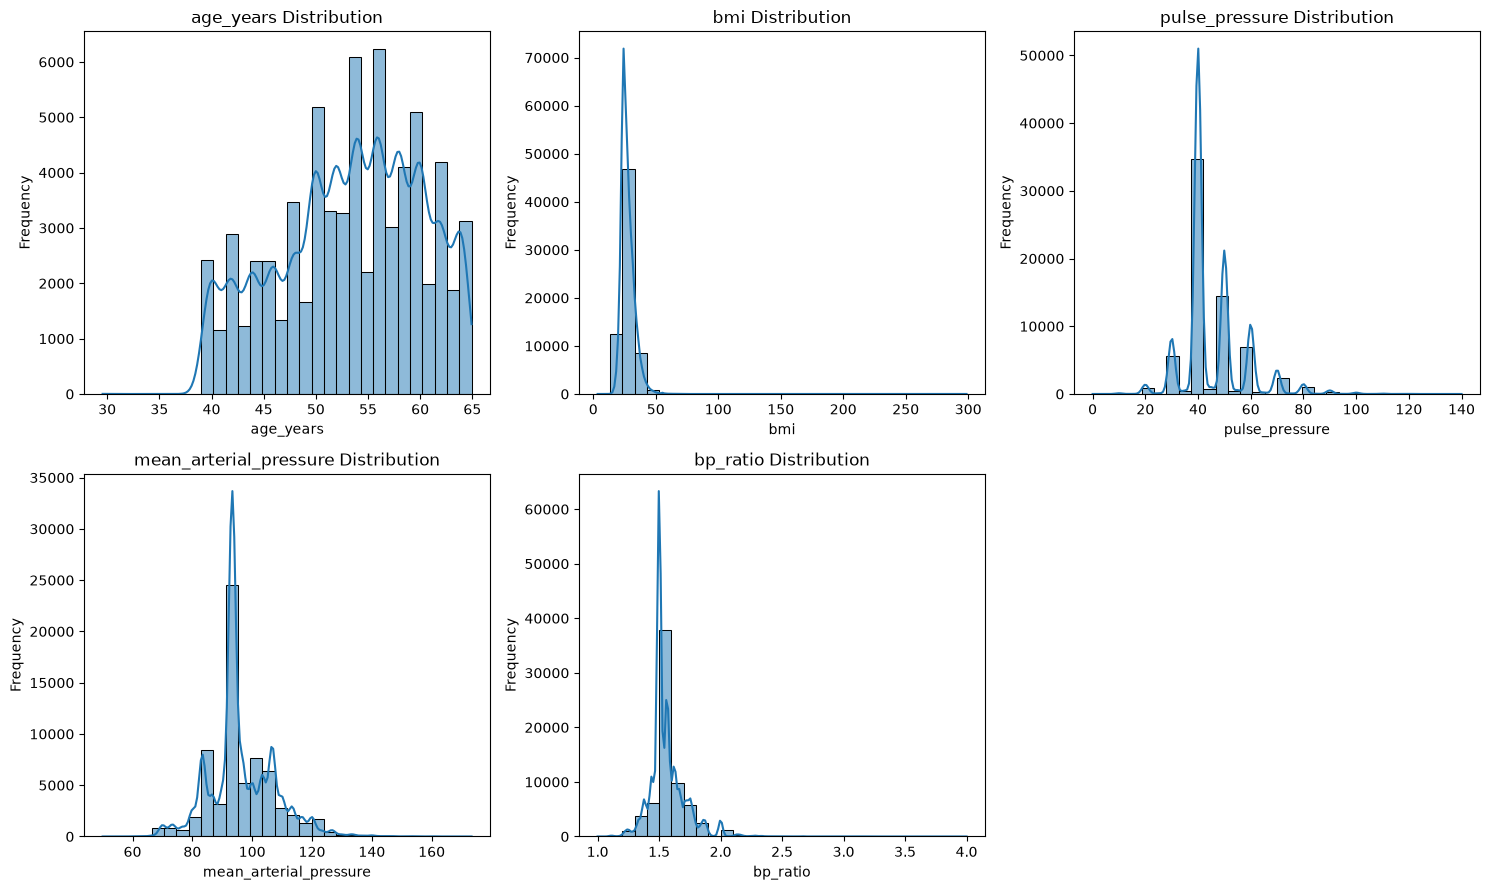

In [18]:
fig, axes = plt.subplots(2, 3, figsize=(15, 9))

for ax, feature in zip(axes.flat, engineered_features):
    sns.histplot(
        df[feature],
        bins=30,
        kde=True,
        ax=ax
    )
    ax.set_title(f"{feature} Distribution")
    ax.set_xlabel(feature)
    ax.set_ylabel("Frequency")

# Hide unused subplot
axes.flat[-1].set_visible(False)

plt.tight_layout()
plt.show()

## Engineered Features and Cardiovascular Disease

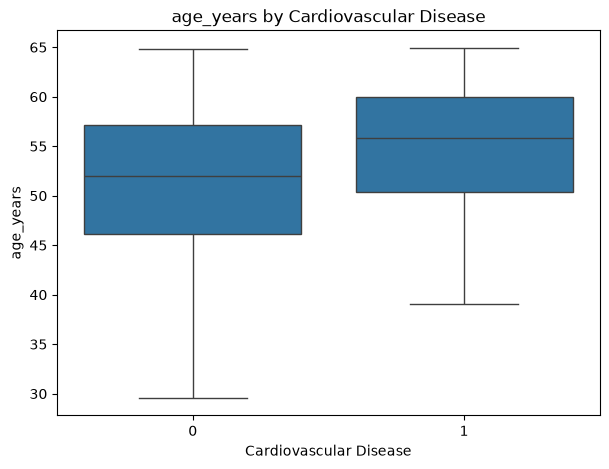

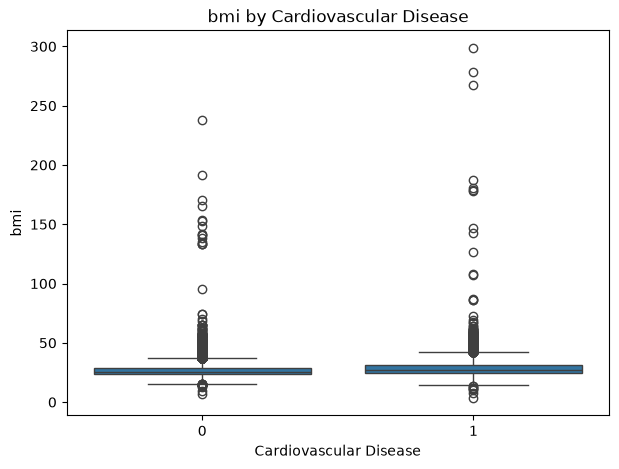

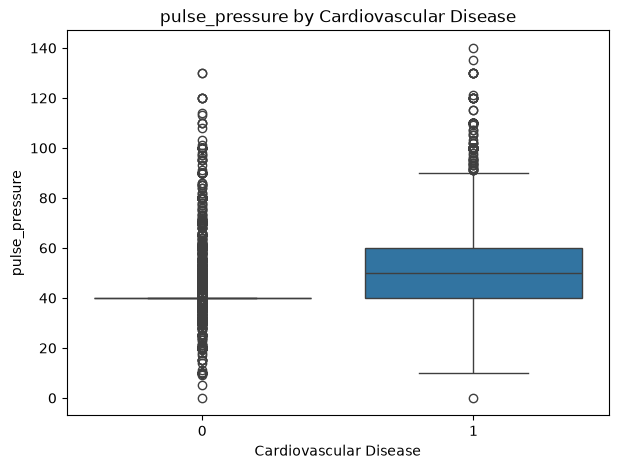

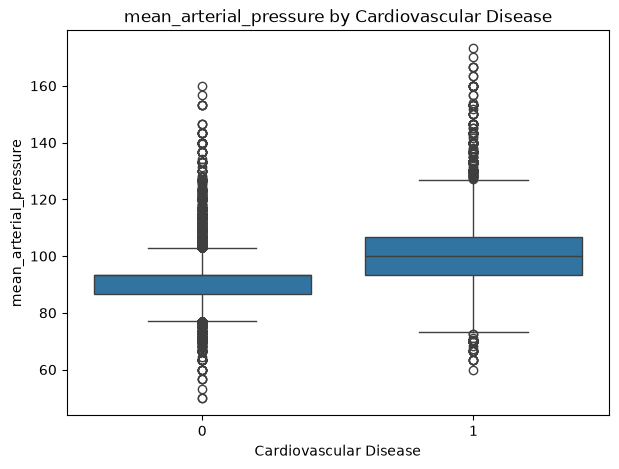

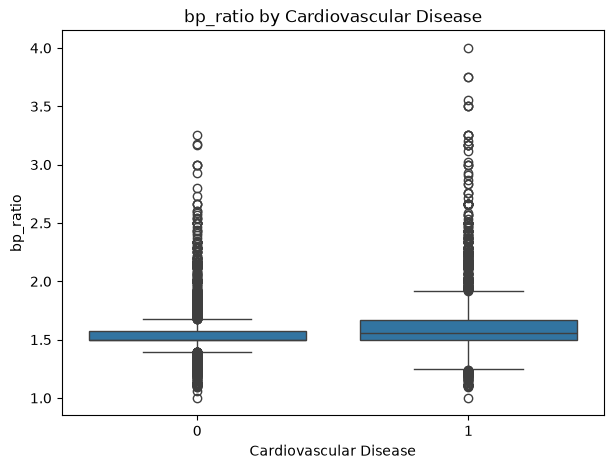

In [19]:
for feature in engineered_features:
    plt.figure(figsize=(7, 5))

    sns.boxplot(
        data=df,
        x="cardio",
        y=feature
    )

    plt.title(f"{feature} by Cardiovascular Disease")
    plt.xlabel("Cardiovascular Disease")
    plt.ylabel(feature)

    plt.show()

## Correlation of Engineered Features with Target

In [20]:
engineered_target_correlation = (
    df[engineered_features + ["cardio"]]
    .corr()["cardio"]
    .drop("cardio")
    .sort_values(ascending=False)
)

engineered_target_correlation

mean_arterial_pressure    0.409839
pulse_pressure            0.336836
age_years                 0.239296
bp_ratio                  0.174356
bmi                       0.164366
Name: cardio, dtype: float64

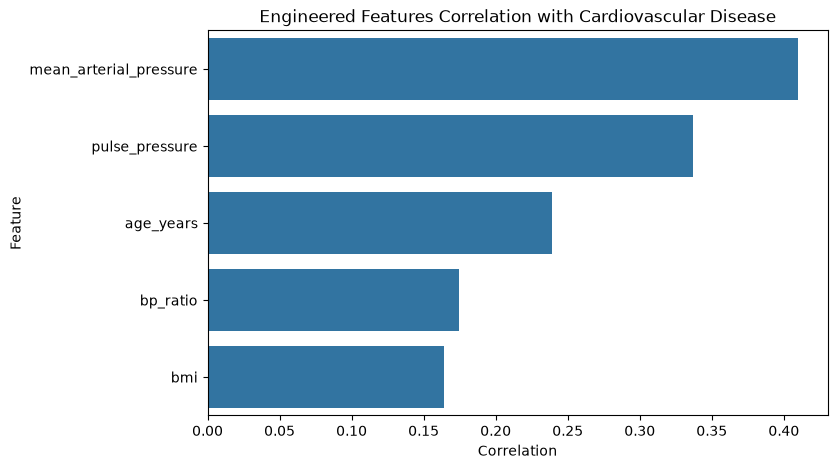

In [21]:
plt.figure(figsize=(8, 5))

sns.barplot(
    x=engineered_target_correlation.values,
    y=engineered_target_correlation.index
)

plt.title("Engineered Features Correlation with Cardiovascular Disease")
plt.xlabel("Correlation")
plt.ylabel("Feature")

plt.show()

## Relationship Between Original and Engineered Features

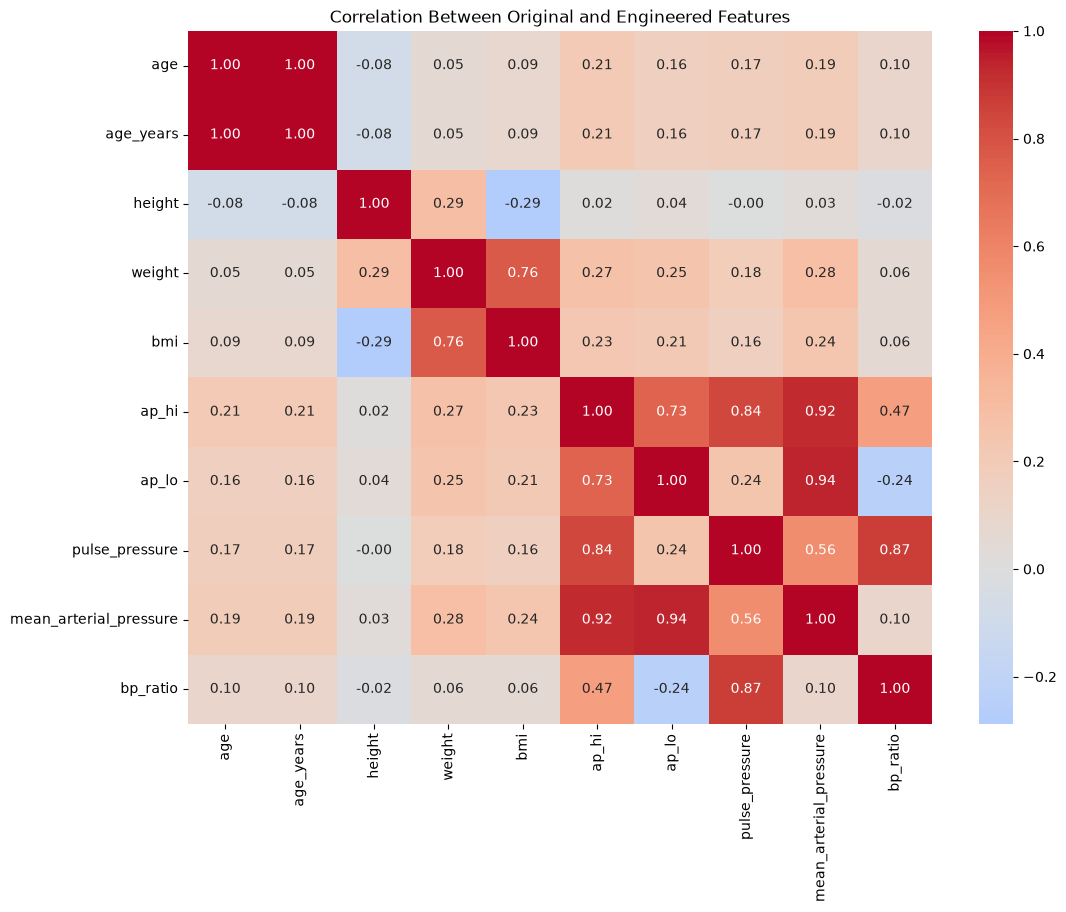

In [22]:
comparison_features = [
    "age",
    "age_years",
    "height",
    "weight",
    "bmi",
    "ap_hi",
    "ap_lo",
    "pulse_pressure",
    "mean_arterial_pressure",
    "bp_ratio"
]

plt.figure(figsize=(12, 9))

sns.heatmap(
    df[comparison_features].corr(),
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Between Original and Engineered Features")

plt.show()

## Drop Original Age

In [23]:
df = df.drop(columns=["age"])

## Remove the Identifier

In [24]:
df = df.drop(columns=["id"])

## Review Final Feature Set

In [25]:
print("Final feature set:\n")

for column in df.columns:
    print(column)

Final feature set:

gender
height
weight
ap_hi
ap_lo
cholesterol
gluc
smoke
alco
active
cardio
age_years
bmi
pulse_pressure
mean_arterial_pressure
bp_ratio


## Final Feature Engineering Validation

In [26]:
print("Dataset shape:", df.shape)

print("\nMissing values:")
print(df.isnull().sum().sum())

print("\nInfinite values:")
print(
    np.isinf(
        df.select_dtypes(include=np.number)
    ).sum().sum()
)

print("\nTarget present:", "cardio" in df.columns)

Dataset shape: (68668, 16)

Missing values:
0

Infinite values:
0

Target present: True


## Export Engineered Dataset

In [28]:
output_path = "../data/processed/cardio_engineered.csv"

df.to_csv(
    output_path,
    index=False
)

print(f"Engineered dataset saved to: {output_path}")

Engineered dataset saved to: ../data/processed/cardio_engineered.csv


## 19. Feature Engineering Summary

The following features were engineered:

| Engineered Feature | Source Features | Purpose |
|---|---|---|
| `age_years` | `age` | More interpretable representation of age |
| `bmi` | `height`, `weight` | Combined measure of body size |
| `pulse_pressure` | `ap_hi`, `ap_lo` | Difference between systolic and diastolic pressure |
| `mean_arterial_pressure` | `ap_hi`, `ap_lo` | Approximate combined blood-pressure measure |
| `bp_ratio` | `ap_hi`, `ap_lo` | Relative relationship between systolic and diastolic pressure |

The original `age` representation was removed after creating `age_years`, and the identifier `id` was removed because it does not represent a meaningful predictive characteristic.

The engineered dataset has been validated and exported.

Feature selection, train-test splitting, encoding, scaling, and other model-oriented preprocessing will be performed in subsequent stages.